# Benchmark Model Training (Self-Contained)

This notebook trains and evaluates baseline models for emotion classification.

**Objective**: Establish performance baseline with simple models - a minimum viable product.

**Data Source**: Loads `Combined_Emotion_Data.csv` directly (no need to run notebooks 05 or 09)

**Models**:
1. **Logistic Regression** - Simple linear baseline
2. **XGBoost** - Non-linear tree-based baseline

**Evaluation**: Focus on **Macro F1-score** due to class imbalance.

## Setup and Imports

In [1]:
import boto3
import sagemaker
import pandas as pd
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
from time import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

print(f"SageMaker version: {sagemaker.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
SageMaker version: 2.245.0
Pandas version: 2.3.3
NumPy version: 1.26.4


In [2]:
# Initialize SageMaker session and S3 client
sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
s3_client = boto3.client('s3', region_name=region)

print(f"Region: {region}")
print(f"Bucket: {bucket}")
print(f"Role: {role}")

Region: us-east-1
Bucket: sagemaker-us-east-1-418418308994
Role: arn:aws:iam::418418308994:role/LabRole


In [3]:
# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# S3 paths for saving models
s3_benchmarks_prefix = f"s3://{bucket}/models/benchmarks"

print(f"Benchmarks will be saved to: {s3_benchmarks_prefix}")

Benchmarks will be saved to: s3://sagemaker-us-east-1-418418308994/models/benchmarks


## Load and Prepare Data

In [4]:
# Load Combined_Emotion_Data.csv
local_file = "Datasets/Combined_Emotion_Data.csv"

if not os.path.exists(local_file):
    print(f"[ERROR] File not found: {local_file}")
    print("\nPlease ensure Combined_Emotion_Data.csv exists in the Datasets/ directory")
    raise FileNotFoundError(f"Missing required file: {local_file}")

print(f"Loading data from {local_file}...")
df = pd.read_csv(local_file)

print(f"\n[OK] Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Loading data from Datasets/Combined_Emotion_Data.csv...

[OK] Data loaded successfully!
Dataset shape: (12803, 23)
Columns: ['row_id', 's3_key_s', 'meanfreq', 'sd', 'median', 'q25', 'q75', 'iqr', 'skew', 'kurt', 'sp_ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx', 'label']


,row_id,s3_key_s,meanfreq,sd,median,q25,q75,iqr,skew,kurt,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0,1,0.181338,0.060495,0.187476,0.126197,0.233586,0.107389,0.869088,2.863717,...,0.181338,0.137742,0.023022,0.271186,0.777344,0.085938,6.226562,6.140625,0.116586,sad
1,1,2,0.186897,0.062260,0.195070,0.130847,0.243987,0.113140,1.191767,3.878650,...,0.186897,0.121811,0.018412,0.271186,0.930339,0.085938,4.000000,3.914062,0.144983,sad
2,2,3,0.189102,0.062901,0.204945,0.131422,0.249978,0.118556,1.312690,4.589995,...,0.189102,0.123758,0.083333,0.262295,0.332386,0.085938,0.625000,0.539062,0.334783,sad
3,4,5,0.183036,0.060051,0.174115,0.129949,0.236967,0.107017,1.096409,3.680995,...,0.183036,0.128469,0.044693,0.258065,1.012019,0.085938,5.468750,5.382812,0.304910,sad
4,5,6,0.168793,0.057910,0.156266,0.116783,0.216326,0.099543,1.386837,5.031744,...,0.168793,0.109720,0.022472,0.235294,0.228795,0.093750,0.750000,0.656250,0.306777,sad


In [5]:
# Check data quality
print("Data Quality Check:\n")

# Missing values
missing = df.isnull().sum()
print(f"Missing values: {missing.sum()} total")
if missing.sum() > 0:
    print(missing[missing > 0])

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Label distribution
print(f"\nLabel distribution:")
print(df['label'].value_counts().sort_index())

Data Quality Check:

Missing values: 0 total

Duplicate rows: 0

Label distribution:
label
Angry        2167
Disgusted    1863
Fearful      2047
Happy        2167
Neutral      1795
Sad          2167
Suprised      592
sad             5
Name: count, dtype: int64


## Data Preprocessing

In [6]:
# Standardize labels to title case (fixes 'sad' vs 'Sad' issue)
df['label'] = df['label'].str.title()

print("Labels after standardization:")
print(df['label'].value_counts().sort_index())
print(f"\nTotal samples: {len(df)}")

Labels after standardization:
label
Angry        2167
Disgusted    1863
Fearful      2047
Happy        2167
Neutral      1795
Sad          2172
Suprised      592
Name: count, dtype: int64

Total samples: 12803


In [7]:
# Define feature columns (20 acoustic features from the dataset)
feature_cols = [
    'meanfreq', 'sd', 'median', 'q25', 'q75', 'iqr', 'skew', 'kurt',
    'sp_ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun',
    'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx'
]

print(f"Using {len(feature_cols)} acoustic features:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Using 20 acoustic features:
   1. meanfreq
   2. sd
   3. median
   4. q25
   5. q75
   6. iqr
   7. skew
   8. kurt
   9. sp_ent
  10. sfm
  11. mode
  12. centroid
  13. meanfun
  14. minfun
  15. maxfun
  16. meandom
  17. mindom
  18. maxdom
  19. dfrange
  20. modindx


## Label Encoding

In [8]:
# Encode labels
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

print("Label encoding:")
for label, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    count = (df['label'] == label).sum()
    print(f"  {code}: {label:12s} ({count:5d} samples, {count/len(df)*100:5.2f}%)")

Label encoding:
  0: Angry        ( 2167 samples, 16.93%)
  1: Disgusted    ( 1863 samples, 14.55%)
  2: Fearful      ( 2047 samples, 15.99%)
  3: Happy        ( 2167 samples, 16.93%)
  4: Neutral      ( 1795 samples, 14.02%)
  5: Sad          ( 2172 samples, 16.96%)
  6: Suprised     (  592 samples,  4.62%)


## Train/Test Split (80/20)

In [9]:
# Stratified split to maintain class distribution
print("Performing train/test split...\n")

X = df[feature_cols]
y = df['label_encoded']

print(f"Before split: X shape = {X.shape}, y shape = {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print(f"\nTrain/Test Split:")
print(f"  Training: {len(X_train):5d} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Test:     {len(X_test):5d} samples ({len(X_test)/len(df)*100:.1f}%)")
print(f"  Total:    {len(df):5d} samples")

Performing train/test split...

Before split: X shape = (12803, 20), y shape = (12803,)

Train/Test Split:
  Training: 10242 samples (80.0%)
  Test:      2561 samples (20.0%)
  Total:    12803 samples


In [10]:
# Apply StandardScaler to normalize features
scaler = StandardScaler()

# Fit on training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied (StandardScaler)")
print(f"  Mean ≈ 0, Std ≈ 1 for all features")
print(f"\nScaled training data shape: {X_train_scaled.shape}")

Feature scaling applied (StandardScaler)
  Mean ≈ 0, Std ≈ 1 for all features

Scaled training data shape: (10242, 20)


In [11]:
# Verify stratification - class distribution should be same in train/test
print("Class distribution verification:\n")

train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()

print("Training set:")
for class_id in range(len(label_encoder.classes_)):
    emotion = label_encoder.classes_[class_id]
    train_pct = train_dist.get(class_id, 0) * 100
    test_pct = test_dist.get(class_id, 0) * 100
    print(f"  {class_id}: {emotion:12s} - Train: {train_pct:5.2f}%, Test: {test_pct:5.2f}%")

# Calculate class imbalance ratio
class_counts = pd.Series(y_train).value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}x")
print("[NOTE] Using balanced class weights and Macro F1-score to handle imbalance")

Class distribution verification:

Training set:
  0: Angry        - Train: 16.92%, Test: 16.95%
  1: Disgusted    - Train: 14.55%, Test: 14.56%
  2: Fearful      - Train: 15.99%, Test: 15.97%
  3: Happy        - Train: 16.93%, Test: 16.91%
  4: Neutral      - Train: 14.02%, Test: 14.02%
  5: Sad          - Train: 16.96%, Test: 16.99%
  6: Suprised     - Train:  4.63%, Test:  4.61%

Class imbalance ratio: 3.66x
[NOTE] Using balanced class weights and Macro F1-score to handle imbalance


### Create CSV for Model Monitoring save Locally and S3

In [12]:
from io import StringIO

#Create baseline from POST-NORMALIZATION train data
baseline_df = pd.DataFrame(X_train)
baseline_df['target'] = y_train
baseline_df.reset_index(drop=True, inplace=True)

print(f"Baseline ready: {baseline_df.shape}, normalized features")
print(baseline_df.head(3))

#LOCAL SAVE (persistent in notebook EBS volume)
local_path = "Datasets/baseline_normalized.csv"
baseline_df.to_csv(local_path, index=False, header=True)
print(f"Local: {local_path}")

#S3 UPLOAD (your code)
bucket = "sagemaker-us-east-1-418418308994"
baseline_key = "models/benchmarks/baseline_normalized.csv"
csv_buffer = StringIO()
baseline_df.to_csv(csv_buffer, index=False, header=True)
s3_resource = boto3.resource('s3')
s3_resource.Object(bucket, baseline_key).put(Body=csv_buffer.getvalue())

baseline_data_uri = f"s3://{bucket}/{baseline_key}"
print(f"S3: {baseline_data_uri}")

#Verify both
print("Local exists:", pd.read_csv(local_path).shape)
print("S3 exists:", pd.read_csv(baseline_data_uri).shape)

Baseline ready: (10242, 21), normalized features
      meanfreq           sd       median       q25        q75         iqr  \
0   544.201696  1246.417379  1059.160363  0.003527 -483.23154  134.644780   
1  4319.791285  3805.004519  7637.572216  0.050685 -683.79850   68.779570   
2  2780.393526  2423.475948  4828.085509  0.134830 -385.00745   63.455914   

        skew       kurt     sp_ent        sfm  ...     centroid     meanfun  \
0  32.268997  39.918340  30.676796  10.320709  ...   544.201696   68.554013   
1 -21.146702   5.744572 -15.622969  -0.198734  ...  4319.791285  162.633847   
2  -9.261029  32.806270  14.690385 -20.325638  ...  2780.393526  177.718861   

       minfun      maxfun    meandom     mindom     maxdom    dfrange  \
0   55.799857   91.172249 -13.276942  -6.071415   9.675461   3.928147   
1  102.930224  195.431994  -3.140631 -12.136674 -19.202915  -0.827022   
2  168.179283  193.187266 -12.040186  -7.366862  10.217881 -19.865255   

    modindx  target  
0  2.06959

## Define Evaluation Functions

In [13]:
def evaluate_model(y_true, y_pred, model_name, label_encoder):
    """
    Comprehensive evaluation for multiclass classification.
    """
    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro': recall_score(y_true, y_pred, average='macro'),
        'f1_per_class': f1_score(y_true, y_pred, average=None).tolist()
    }
    report = classification_report(y_true, y_pred, target_names=label_encoder.classes_, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    return metrics, report, cm

def plot_confusion_matrix(cm, class_names, title, save_path=None):
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def print_metrics(metrics):
    print(f"\n{'='*60}")
    print(f"Model: {metrics['model_name']}")
    print(f"{'='*60}")
    print(f"  Accuracy:          {metrics['accuracy']:.4f}")
    print(f"  F1 (Macro):        {metrics['f1_macro']:.4f} <- PRIMARY METRIC")
    print(f"  F1 (Weighted):     {metrics['f1_weighted']:.4f}")
    print(f"  Precision (Macro): {metrics['precision_macro']:.4f}")
    print(f"  Recall (Macro):    {metrics['recall_macro']:.4f}")
    print(f"\nPer-Class F1 Scores:")
    for i, (class_name, f1) in enumerate(zip(label_encoder.classes_, metrics['f1_per_class'])):
        print(f"  {i}: {class_name:12s} - {f1:.4f}")
    print(f"{'='*60}")

## Model 1: Logistic Regression

In [14]:
print("Training Logistic Regression (One-vs-Rest with balanced class weights)...\n")

start_time = time()

lr_model = LogisticRegression(
    multi_class='ovr',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_train)

lr_train_time = time() - start_time
print(f"[OK] Logistic Regression trained in {lr_train_time:.2f} seconds")

Training Logistic Regression (One-vs-Rest with balanced class weights)...



/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


[OK] Logistic Regression trained in 6.54 seconds


In [15]:
# Make predictions on test set
start_time = time()
y_pred_lr = lr_model.predict(X_test_scaled)
lr_inference_time = time() - start_time

print(f"Predictions completed in {lr_inference_time:.4f} seconds")

Predictions completed in 0.0860 seconds


In [16]:
# Evaluate Logistic Regression
lr_metrics, lr_report, lr_cm = evaluate_model(y_test, y_pred_lr, 'Logistic Regression', label_encoder)
lr_metrics['train_time_sec'] = lr_train_time
lr_metrics['inference_time_sec'] = lr_inference_time

print_metrics(lr_metrics)


Model: Logistic Regression
  Accuracy:          0.4026
  F1 (Macro):        0.4030 <- PRIMARY METRIC
  F1 (Weighted):     0.3971
  Precision (Macro): 0.3983
  Recall (Macro):    0.4431

Per-Class F1 Scores:
  0: Angry        - 0.4937
  1: Disgusted    - 0.3836
  2: Fearful      - 0.3271
  3: Happy        - 0.3388
  4: Neutral      - 0.3848
  5: Sad          - 0.4283
  6: Suprised     - 0.4645


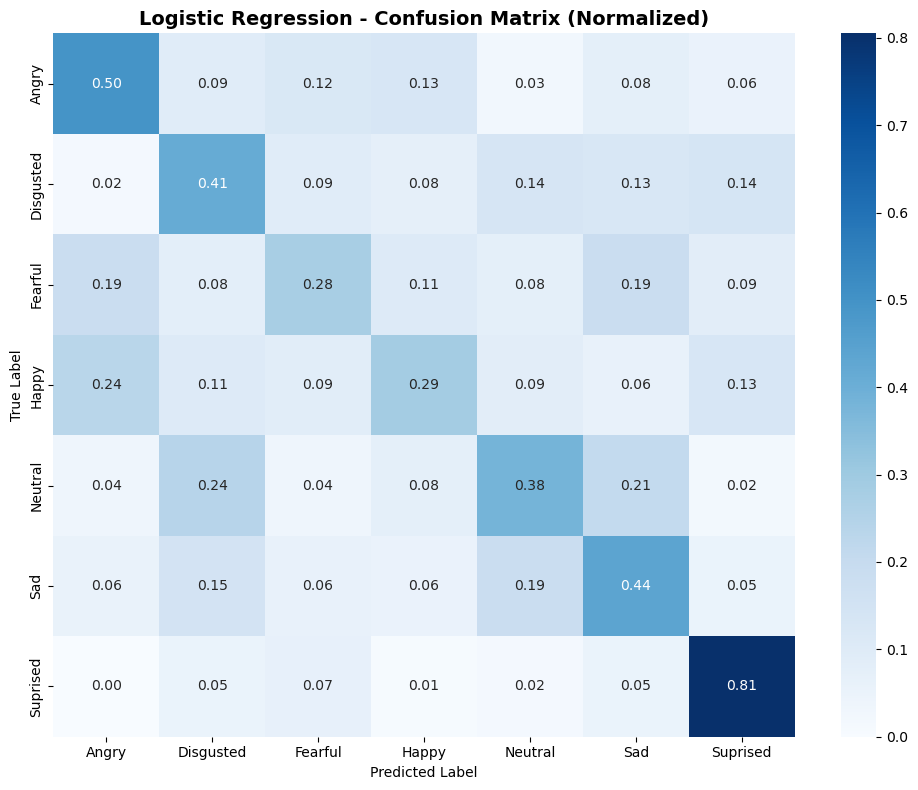

In [17]:
# Plot confusion matrix for Logistic Regression
plot_confusion_matrix(lr_cm, label_encoder.classes_, 
                      'Logistic Regression - Confusion Matrix (Normalized)',
                      save_path='/tmp/lr_confusion_matrix.png')

## Model 2: XGBoost

In [18]:
print("Training XGBoost Classifier...\n")

start_time = time()

# Calculate sample weights for class imbalance
sample_weights = compute_sample_weight('balanced', y_train)

xgb_model = XGBClassifier(
    max_depth=6,
    n_estimators=100,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    use_label_encoder=False,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights, verbose=False)

xgb_train_time = time() - start_time
print(f"[OK] XGBoost trained in {xgb_train_time:.2f} seconds")

Training XGBoost Classifier...



/opt/conda/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [05:58:18] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[OK] XGBoost trained in 4.68 seconds


In [19]:
# Make predictions on test set
start_time = time()
y_pred_xgb = xgb_model.predict(X_test_scaled)
xgb_inference_time = time() - start_time

print(f"Predictions completed in {xgb_inference_time:.4f} seconds")

Predictions completed in 0.0767 seconds


In [20]:
# Evaluate XGBoost
xgb_metrics, xgb_report, xgb_cm = evaluate_model(y_test, y_pred_xgb, 'XGBoost', label_encoder)
xgb_metrics['train_time_sec'] = xgb_train_time
xgb_metrics['inference_time_sec'] = xgb_inference_time

print_metrics(xgb_metrics)


Model: XGBoost
  Accuracy:          0.6209
  F1 (Macro):        0.6357 <- PRIMARY METRIC
  F1 (Weighted):     0.6183
  Precision (Macro): 0.6322
  Recall (Macro):    0.6468

Per-Class F1 Scores:
  0: Angry        - 0.7206
  1: Disgusted    - 0.5429
  2: Fearful      - 0.5268
  3: Happy        - 0.5983
  4: Neutral      - 0.6127
  5: Sad          - 0.6396
  6: Suprised     - 0.8093


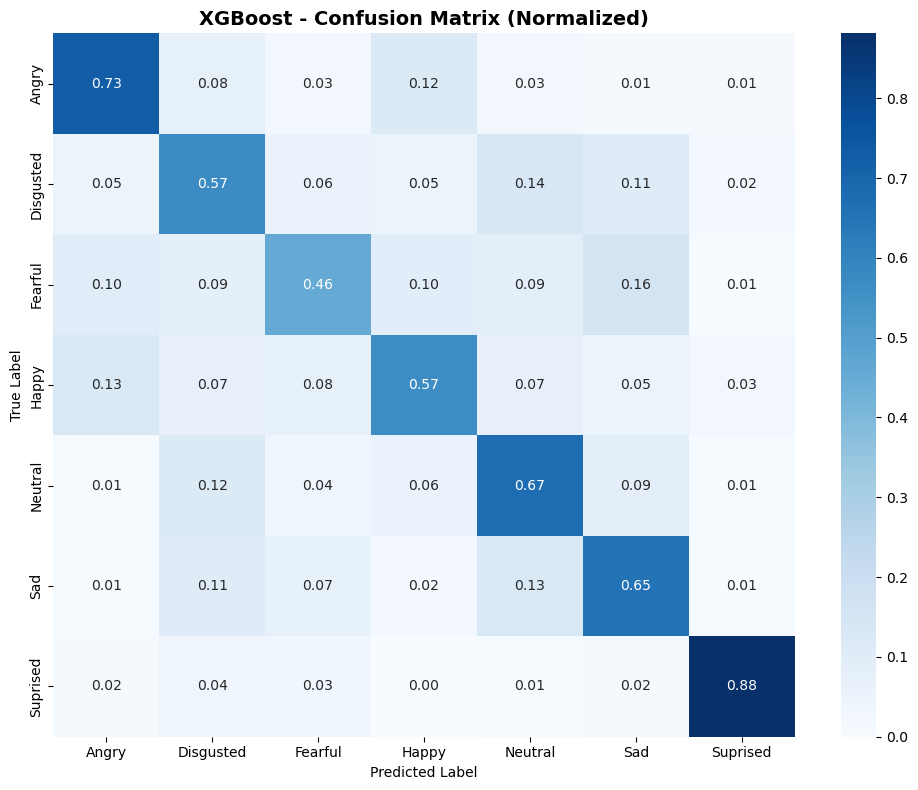

In [21]:
# Plot confusion matrix for XGBoost
plot_confusion_matrix(xgb_cm, label_encoder.classes_, 
                      'XGBoost - Confusion Matrix (Normalized)',
                      save_path='/tmp/xgb_confusion_matrix.png')

In [22]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Feature Importances:")
print(feature_importance.head(10).to_string(index=False))

Top 10 Feature Importances:
 feature  importance
      sd    0.144098
     q75    0.101372
  maxfun    0.077773
  minfun    0.076555
    skew    0.058716
     q25    0.054177
  median    0.049856
    kurt    0.049027
 meanfun    0.042345
meanfreq    0.039948


## Model Comparison

In [23]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'Training Time (s)'],
    'Logistic Regression': [
        lr_metrics['accuracy'],
        lr_metrics['f1_macro'],
        lr_metrics['f1_weighted'],
        lr_metrics['train_time_sec']
    ],
    'XGBoost': [
        xgb_metrics['accuracy'],
        xgb_metrics['f1_macro'],
        xgb_metrics['f1_weighted'],
        xgb_metrics['train_time_sec']
    ]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


MODEL COMPARISON
           Metric  Logistic Regression  XGBoost
         Accuracy             0.402577 0.620851
       F1 (Macro)             0.402964 0.635746
    F1 (Weighted)             0.397134 0.618294
Training Time (s)             6.537927 4.683706


## Save Models to S3 & Local

In [25]:
import io
import os
import tarfile

s3_client = boto3.client('s3')
bucket = "sagemaker-us-east-1-418418308994"

print("Saving models and artifacts to LOCAL + S3...")

# ✅ FIXED: Create Models folder structure
os.makedirs('/tmp/Models/benchmarks/logistic_regression', exist_ok=True)
os.makedirs('/tmp/Models/benchmarks/xgboost', exist_ok=True)

# LOGISTIC REGRESSION 
lr_dir = '/tmp/Models/benchmarks/logistic_regression'  # ✅ Absolute path
lr_model_path = f'{lr_dir}/model.pkl'
lr_metrics_path = f'{lr_dir}/metrics.json'
lr_cm_path = f'{lr_dir}/confusion_matrix.png'

# Local saves
with open(lr_model_path, 'wb') as f:
    pickle.dump(lr_model, f)
print(f"  💾 LR Model (local): {lr_model_path}")

with open(lr_metrics_path, 'w') as f:
    json.dump(lr_metrics, f, indent=2)

# Create dummy CM if missing
if not os.path.exists(lr_cm_path):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,5)); plt.text(0.5,0.5,'LR Confusion Matrix',ha='center'); plt.savefig(lr_cm_path); plt.close()

# LOCAL .tar.gz
lr_tar_path = f'{lr_dir}/model.tar.gz'
tar_buffer = io.BytesIO()
with tarfile.open(fileobj=tar_buffer, mode='w:gz') as tar:
    tar.add(lr_model_path, arcname='model.pkl')
    tar.add(lr_metrics_path, arcname='metrics.json')
    tar.add(lr_cm_path, arcname='confusion_matrix.png')
tar_buffer.seek(0)
with open(lr_tar_path, 'wb') as f:
    f.write(tar_buffer.getvalue())
print(f"  💾 LR Model.tar.gz: {lr_tar_path}")

# S3 uploads
s3_client.upload_file(lr_model_path, bucket, 'models/benchmarks/logistic_regression/model.pkl')
s3_client.upload_file(lr_tar_path, bucket, 'models/benchmarks/logistic_regression/model.tar.gz')
s3_client.upload_file(lr_metrics_path, bucket, 'models/benchmarks/logistic_regression/metrics.json')
s3_client.upload_file(lr_cm_path, bucket, 'models/benchmarks/logistic_regression/confusion_matrix.png')
print(f"  ☁️  LR: s3://{bucket}/models/benchmarks/logistic_regression/model.tar.gz")

# XGBOOST 
xgb_dir = '/tmp/Models/benchmarks/xgboost'
os.makedirs(xgb_dir, exist_ok=True)

xgb_model_path = f'{xgb_dir}/model.pkl'  # Keep pickle for local use
with open(xgb_model_path, 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"  💾 XGB Model.pkl (local): {xgb_model_path}")

# NATIVE BINARY for SageMaker (key fix!)
booster = xgb_model.get_booster()
native_path = f'{xgb_dir}/xgboost-model'
booster.save_model(native_path)
print(f"  🔧 Native xgboost-model: {native_path}")

# LOCAL .tar.gz - ONLY native binary!
xgb_tar_path = f'{xgb_dir}/model.tar.gz'  # ✅ Now defined
with tarfile.open(xgb_tar_path, 'w:gz') as tar:
    tar.add(native_path, arcname='xgboost-model')  # Single file!

print(f"  💾 XGB model.tar.gz: {xgb_tar_path}")

# Metrics (keep separate)
xgb_metrics_path = f'{xgb_dir}/metrics.json'
with open(xgb_metrics_path, 'w') as f:
    json.dump(xgb_metrics, f, indent=2)

# CM (if exists)
xgb_cm_path = f'{xgb_dir}/confusion_matrix.png'
if not os.path.exists(xgb_cm_path):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,5)); plt.text(0.5,0.5,'XGB Confusion Matrix'); plt.savefig(xgb_cm_path); plt.close()

# S3 uploads
s3_client.upload_file(xgb_model_path, bucket, 'models/benchmarks/xgboost/model.pkl')
s3_client.upload_file(xgb_tar_path, bucket, 'models/benchmarks/xgboost/model.tar.gz')
s3_client.upload_file(xgb_metrics_path, bucket, 'models/benchmarks/xgboost/metrics.json')
s3_client.upload_file(xgb_cm_path, bucket, 'models/benchmarks/xgboost/confusion_matrix.png')
print(f"  ☁️  XGB: s3://{bucket}/models/benchmarks/xgboost/model.tar.gz")


# COMPARISON
comp_dir = '/tmp/Models/benchmarks'
os.makedirs(comp_dir, exist_ok=True)
comp_path = f'{comp_dir}/benchmark_comparison.json'

best_model = 'xgboost' if xgb_metrics['f1_macro'] > lr_metrics['f1_macro'] else 'logistic_regression'
comparison = {
    'timestamp': datetime.now().isoformat(),
    'best_model': best_model,
    'best_f1_macro': max(lr_metrics['f1_macro'], xgb_metrics['f1_macro']),
    'models': {'logistic_regression': lr_metrics, 'xgboost': xgb_metrics}
}
with open(comp_path, 'w') as f:
    json.dump(comparison, f, indent=2)
s3_client.upload_file(comp_path, bucket, 'models/benchmarks/benchmark_comparison.json')
print(f"  📊 Comparison: {comp_path}")

print("\n🎉 [OK] All artifacts saved to /tmp/Models + S3 (.pkl + .tar.gz)")

Saving models and artifacts to LOCAL + S3...
  💾 LR Model (local): /tmp/Models/benchmarks/logistic_regression/model.pkl
  💾 LR Model.tar.gz: /tmp/Models/benchmarks/logistic_regression/model.tar.gz
  ☁️  LR: s3://sagemaker-us-east-1-418418308994/models/benchmarks/logistic_regression/model.tar.gz
  💾 XGB Model.pkl (local): /tmp/Models/benchmarks/xgboost/model.pkl
  🔧 Native xgboost-model: /tmp/Models/benchmarks/xgboost/xgboost-model


/opt/conda/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [06:01:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


  💾 XGB model.tar.gz: /tmp/Models/benchmarks/xgboost/model.tar.gz
  ☁️  XGB: s3://sagemaker-us-east-1-418418308994/models/benchmarks/xgboost/model.tar.gz
  📊 Comparison: /tmp/Models/benchmarks/benchmark_comparison.json

🎉 [OK] All artifacts saved to /tmp/Models + S3 (.pkl + .tar.gz)


## Summary

In [26]:
print("="*70)
print("BENCHMARK MODEL TRAINING - COMPLETE")
print("="*70)

print(f"\nDataset: {len(df):,} samples, {len(feature_cols)} features, {len(label_encoder.classes_)} classes")
print(f"Train/Test: {len(X_train):,} / {len(X_test):,}")

print(f"\nResults:")
print(f"  Logistic Regression: F1 (Macro) = {lr_metrics['f1_macro']:.4f}")
print(f"  XGBoost:             F1 (Macro) = {xgb_metrics['f1_macro']:.4f}")

print(f"\nBest Model: {best_model.replace('_', ' ').title()}")
print(f"\nModels saved to: s3://{bucket}/models/benchmarks/")
print("="*70)

BENCHMARK MODEL TRAINING - COMPLETE

Dataset: 12,803 samples, 20 features, 7 classes
Train/Test: 10,242 / 2,561

Results:
  Logistic Regression: F1 (Macro) = 0.4030
  XGBoost:             F1 (Macro) = 0.6357

Best Model: Xgboost

Models saved to: s3://sagemaker-us-east-1-418418308994/models/benchmarks/


## Release Resources

In [27]:
%%html
<p><b>Shutting down your kernel for this notebook to release resources.</b></p>
<button class="sm-command-button" data-commandlinker-command="kernelmenu:shutdown" style="display:none;">Shutdown Kernel</button>
<script>
try {
    els = document.getElementsByClassName("sm-command-button");
    els[0].click();
}
catch(err) {
    // NoOp
}    
</script>